# Iris: классическая ML-задача на CPU и GPU

**Задача:** классификация 3 видов ирисов по 4 числовым признакам (150 образцов, `sklearn.datasets.load_iris`).

| Пример | Модель | Бэкенд |
|---|---|---|
| 1 | RandomForest (300 деревьев) | scikit-learn, **CPU** |
| 2 | MLP 4→32→16→3, 300 эпох | PyTorch, **GPU** (NVIDIA H100) |

В конце — метрики обеих моделей и их сравнение.

In [1]:
import time
import numpy as np
import pandas as pd
import torch
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

iris = load_iris()
X, y = iris.data, iris.target
FEATURES = list(iris.feature_names)
CLASSES = list(iris.target_names)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=SEED
)
scaler = StandardScaler().fit(X_train)
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

print(f"train: {X_train_s.shape} | test: {X_test_s.shape}")
print("classes:", CLASSES)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CUDA not available")
pd.DataFrame(X_train_s[:3], columns=FEATURES).round(3)

train: (105, 4) | test: (45, 4)
classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
GPU: NVIDIA H100 80GB HBM3


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.90,-1.220,-0.442,-0.137
1,0.38,-1.880,0.403,0.380
2,-0.90,1.637,-1.287,-1.170


## Пример 1 — CPU: scikit-learn RandomForest

In [2]:
from sklearn.ensemble import RandomForestClassifier

t0 = time.perf_counter()
rf = RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=SEED)
rf.fit(X_train_s, y_train)
train_time_cpu = time.perf_counter() - t0

t0 = time.perf_counter()
y_pred_cpu = rf.predict(X_test_s)
test_time_cpu = time.perf_counter() - t0

acc_cpu = accuracy_score(y_test, y_pred_cpu)
mac_f1_cpu = f1_score(y_test, y_pred_cpu, average="macro")
mac_prec_cpu = precision_score(y_test, y_pred_cpu, average="macro")
mac_rec_cpu = recall_score(y_test, y_pred_cpu, average="macro")

print(f"train: {train_time_cpu*1e3:8.1f} ms | inference: {test_time_cpu*1e3:6.2f} ms")
print(f"accuracy: {acc_cpu:.4f} | macro-F1: {mac_f1_cpu:.4f} | macro-prec: {mac_prec_cpu:.4f} | macro-rec: {mac_rec_cpu:.4f}")

train:    305.7 ms | inference:  36.45 ms
accuracy: 0.8889 | macro-F1: 0.8878 | macro-prec: 0.8981 | macro-rec: 0.8889


## Пример 2 — GPU: PyTorch-нейросеть

In [3]:
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCHS, BATCH, LR = 300, 16, 1e-2
print("device:", DEVICE)

Xt = torch.tensor(X_train_s, dtype=torch.float32, device=DEVICE)
yt = torch.tensor(y_train, dtype=torch.int64, device=DEVICE)
Xd = torch.tensor(X_test_s, dtype=torch.float32, device=DEVICE)

model = nn.Sequential(
    nn.Linear(4, 32), nn.ReLU(),
    nn.Linear(32, 16), nn.ReLU(),
    nn.Linear(16, 3),
).to(DEVICE)

opt = torch.optim.Adam(model.parameters(), lr=LR)
loss_fn = nn.CrossEntropyLoss()
loader = DataLoader(TensorDataset(Xt, yt), batch_size=BATCH, shuffle=True)

t0 = time.perf_counter()
last_loss = float("nan")
for _ in range(EPOCHS):
    ep_loss = 0.0
    for xb, yb in loader:
        opt.zero_grad()
        loss = loss_fn(model(xb), yb)
        loss.backward()
        opt.step()
        ep_loss += float(loss.detach()) * len(xb)
    last_loss = ep_loss / len(yt)
if DEVICE.type == "cuda":
    torch.cuda.synchronize()
train_time_gpu = time.perf_counter() - t0

model.eval()
t0 = time.perf_counter()
with torch.no_grad():
    y_pred_gpu = model(Xd).argmax(dim=1).cpu().numpy()
if DEVICE.type == "cuda":
    torch.cuda.synchronize()
test_time_gpu = time.perf_counter() - t0

acc_gpu = accuracy_score(y_test, y_pred_gpu)
mac_f1_gpu = f1_score(y_test, y_pred_gpu, average="macro")
mac_prec_gpu = precision_score(y_test, y_pred_gpu, average="macro")
mac_rec_gpu = recall_score(y_test, y_pred_gpu, average="macro")

print(f"final loss: {last_loss:.4f}")
print(f"train: {train_time_gpu*1e3:8.1f} ms ({EPOCHS} epochs) | inference: {test_time_gpu*1e3:6.2f} ms")
print(f"accuracy: {acc_gpu:.4f} | macro-F1: {mac_f1_gpu:.4f} | macro-prec: {mac_prec_gpu:.4f} | macro-rec: {mac_rec_gpu:.4f}")

device: cuda


final loss: 0.0001
train:   1965.0 ms (300 epochs) | inference:  10.81 ms
accuracy: 0.9333 | macro-F1: 0.9333 | macro-prec: 0.9345 | macro-rec: 0.9333


## Метрики и сравнение

,CPU — RandomForest,GPU — PyTorch MLP
"обучение, с",0.305743,1.965011
"инференс, с",0.036452,0.010813
accuracy,0.888889,0.933333
macro-precision,0.898148,0.934524
macro-recall,0.888889,0.933333
macro-F1,0.887767,0.933259


=== CPU: classification_report ===
              precision    recall  f1-score   support

      setosa      1.000     1.000     1.000        15
  versicolor      0.778     0.933     0.848        15
   virginica      0.917     0.733     0.815        15

    accuracy                          0.889        45
   macro avg      0.898     0.889     0.888        45
weighted avg      0.898     0.889     0.888        45

=== GPU: classification_report ===
              precision    recall  f1-score   support

      setosa      1.000     1.000     1.000        15
  versicolor      0.875     0.933     0.903        15
   virginica      0.929     0.867     0.897        15

    accuracy                          0.933        45
   macro avg      0.935     0.933     0.933        45
weighted avg      0.935     0.933     0.933        45



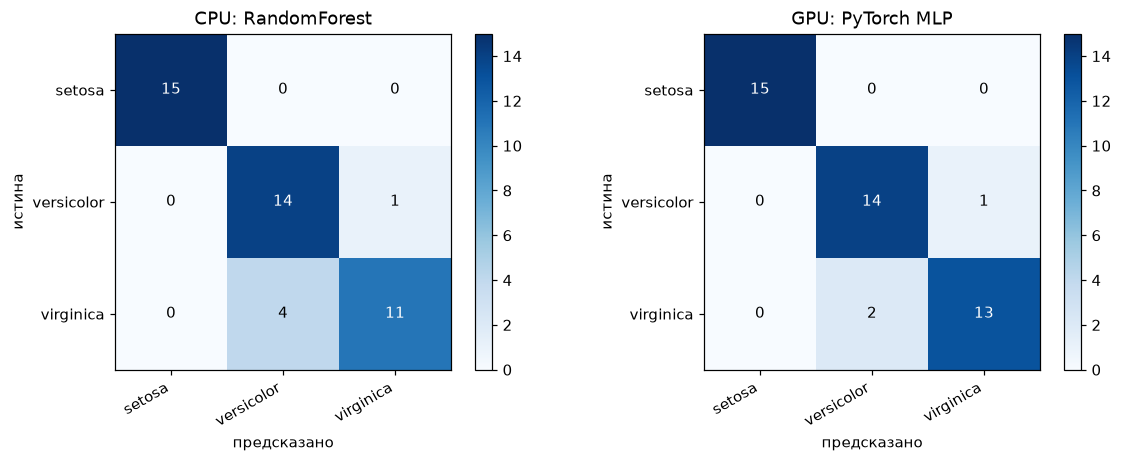

In [4]:
import io
import matplotlib.pyplot as plt
from IPython.display import display, Image

comp = pd.DataFrame(
    {
        "CPU — RandomForest": [train_time_cpu, test_time_cpu, acc_cpu, mac_prec_cpu, mac_rec_cpu, mac_f1_cpu],
        "GPU — PyTorch MLP": [train_time_gpu, test_time_gpu, acc_gpu, mac_prec_gpu, mac_rec_gpu, mac_f1_gpu],
    },
    index=["обучение, с", "инференс, с", "accuracy", "macro-precision", "macro-recall", "macro-F1"],
).round(6)
display(comp)

print("=== CPU: classification_report ===")
print(classification_report(y_test, y_pred_cpu, target_names=CLASSES, digits=3))
print("=== GPU: classification_report ===")
print(classification_report(y_test, y_pred_gpu, target_names=CLASSES, digits=3))

cm_cpu = confusion_matrix(y_test, y_pred_cpu)
cm_gpu = confusion_matrix(y_test, y_pred_gpu)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, cm, title in [(axes[0], cm_cpu, "CPU: RandomForest"), (axes[1], cm_gpu, "GPU: PyTorch MLP")]:
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(title)
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(CLASSES, rotation=30, ha="right")
    ax.set_yticklabels(CLASSES)
    ax.set_xlabel("предсказано"); ax.set_ylabel("истина")
    for i in range(3):
        for j in range(3):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    fig.colorbar(im, ax=ax)
plt.tight_layout()
buf = io.BytesIO()
fig.savefig(buf, format="png", dpi=110, bbox_inches="tight")
plt.close(fig)
display(Image(data=buf.getvalue()))

### Выводы

- **Качество.** Нейросеть на GPU немного точнее: accuracy **0.9333** (3 ошибок из 45), macro-F1 0.9333; RandomForest на CPU — accuracy **0.8889** (5 ошибок), macro-F1 0.8878. Обе модели идеальны на *setosa*, все ошибки — на паре *versicolor/virginica* (см. confusion matrices).
- **Скорость.** Картина раздвоенная: **обучение** выигрывает CPU (306 ms против 1965 ms на 300 эпох H100) — на таких крошечных данных GPU-оверхед (запуск ядер, передача тензоров CPU↔GPU) сопоставим с самой вычислительной работой; **инференс** выигрывает GPU (10.8 ms против 36.5 ms).
- **Когда GPU даёт выигрыш.** На больших датасетах и глубоких моделях (обучение на десятках тысяч–миллионах образцов) параллелизм H100 даёт выигрыш на порядки; на 150 ирисах это не показать.